## EDA and Preprocessing

### Setup & Load the Correct Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('Employee.csv')

# Display the first few rows
df.head()


,Company,Age,Salary,Place,Country,Gender
0,TCS,20.0,NaN,Chennai,India,0
1,Infosys,30.0,NaN,Mumbai,India,0
2,TCS,35.0,2300.0,Calcutta,India,0
3,Infosys,40.0,3000.0,Delhi,India,0
4,TCS,23.0,4000.0,Mumbai,India,0


### Data Exploration 
1 List unique values in each feature and their counts

In [2]:
for col in df.columns:
    unique_vals = df[col].unique()
    print(f"Column: {col}")
    print(f"Unique values: {unique_vals}")
    print(f"Number of unique values: {len(unique_vals)}\n")


Column: Company
Unique values: ['TCS' 'Infosys' 'CTS' nan 'Tata Consultancy Services' 'Congnizant'
 'Infosys Pvt Lmt']
Number of unique values: 7

Column: Age
Unique values: [20. 30. 35. 40. 23. nan 34. 45. 18. 22. 32. 37. 50. 21. 46. 36. 26. 41.
 24. 25. 43. 19. 38. 51. 31. 44. 33. 17.  0. 54.]
Number of unique values: 30

Column: Salary
Unique values: [  nan 2300. 3000. 4000. 5000. 6000. 7000. 8000. 9000. 1089. 1234. 3030.
 3045. 3184. 4824. 5835. 7084. 8943. 8345. 9284. 9876. 2034. 7654. 2934.
 4034. 5034. 8202. 9024. 4345. 6544. 6543. 3234. 4324. 5435. 5555. 8787.
 3454. 5654. 5009. 5098. 3033.]
Number of unique values: 41

Column: Place
Unique values: ['Chennai' 'Mumbai' 'Calcutta' 'Delhi' 'Podicherry' 'Cochin' nan 'Noida'
 'Hyderabad' 'Bhopal' 'Nagpur' 'Pune']
Number of unique values: 12

Column: Country
Unique values: ['India']
Number of unique values: 1

Column: Gender
Unique values: [0 1]
Number of unique values: 2



2 Statistical analysis

In [3]:
df.describe(include='all')  # Includes both numeric and categorical columns


,Company,Age,Salary,Place,Country,Gender
count,140,130.000000,124.000000,134,148,148.000000
unique,6,NaN,NaN,11,1,NaN
top,TCS,NaN,NaN,Mumbai,India,NaN
freq,53,NaN,NaN,37,148,NaN
mean,NaN,30.484615,5312.467742,NaN,NaN,0.222973
std,NaN,11.096640,2573.764683,NaN,NaN,0.417654
min,NaN,0.000000,1089.000000,NaN,NaN,0.000000
25%,NaN,22.000000,3030.000000,NaN,NaN,0.000000
50%,NaN,32.500000,5000.000000,NaN,NaN,0.000000
75%,NaN,37.750000,8000.000000,NaN,NaN,0.000000


3 Rename columns 

In [5]:
df.columns = [col.strip().lower().replace(' ', '_') for col in df.columns]
df.head()


,company,age,salary,place,country,gender
0,TCS,20.0,NaN,Chennai,India,0
1,Infosys,30.0,NaN,Mumbai,India,0
2,TCS,35.0,2300.0,Calcutta,India,0
3,Infosys,40.0,3000.0,Delhi,India,0
4,TCS,23.0,4000.0,Mumbai,India,0


## Data Cleaning

1 Find missing and inappropriate values

In [6]:
# Check for missing values
print("Missing values in each column:")
print(df.isnull().sum())

# Check for data types and inappropriate formats
print("\nData types:")
print(df.dtypes)


Missing values in each column:
company     8
age        18
salary     24
place      14
country     0
gender      0
dtype: int64

Data types:
company     object
age        float64
salary     float64
place       object
country     object
gender       int64
dtype: object


2 Remove duplicate rows

In [7]:
# Remove duplicates
df = df.drop_duplicates()
print("Duplicates removed. New shape:", df.shape)


Duplicates removed. New shape: (144, 6)


3 Find outliers using boxplots

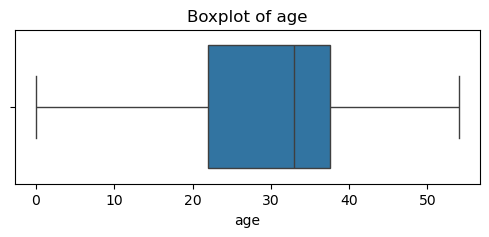

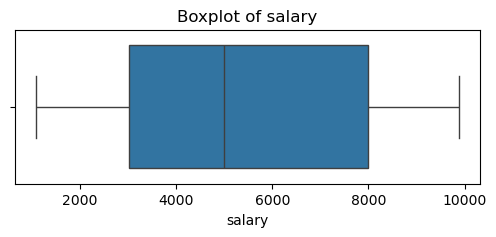

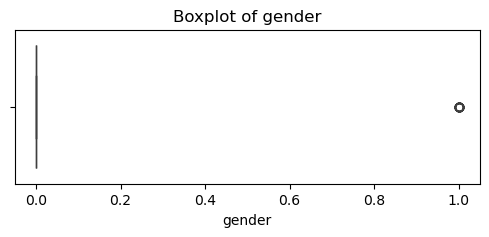

In [8]:
# Visualize numeric columns to spot outliers
numeric_cols = df.select_dtypes(include=[np.number]).columns

# Plot boxplots for each numeric column
import matplotlib.pyplot as plt
import seaborn as sns

for col in numeric_cols:
    plt.figure(figsize=(6, 2))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()


4 Replace 0 in age column with NaN

In [14]:
# Replace age = 0 with NaN (assuming age can't be zero)
df['age'] = df['age'].replace(0, np.nan)


5 Treat all null values (fill with mean/median/mode)

In [16]:
# Fill numeric columns with mean
for col in df.select_dtypes(include=[np.number]):
    df[col] = df[col].fillna(df[col].mean())

# Fill categorical columns with mode
for col in df.select_dtypes(include=['object']):
    df[col] = df[col].fillna(df[col].mode()[0])

# Check again to confirm no missing values
df.isnull().sum()

company    0
age        0
salary     0
place      0
country    0
gender     0
dtype: int64

## Data Analysis (Filtering + Plotting)

1 Filter data with age > 40 and salary < 5000

In [17]:
filtered_df = df[(df['age'] > 40) & (df['salary'] < 5000)]
print(filtered_df)


     company   age  salary      place country  gender
21   Infosys  50.0  3184.0      Delhi   India       0
32   Infosys  45.0  4034.0   Calcutta   India       0
39   Infosys  41.0  3000.0     Mumbai   India       0
50   Infosys  41.0  3000.0    Chennai   India       0
57   Infosys  51.0  3184.0  Hyderabad   India       0
68   Infosys  43.0  4034.0     Mumbai   India       0
75   Infosys  44.0  3000.0     Cochin   India       0
86   Infosys  41.0  3000.0      Delhi   India       0
93   Infosys  54.0  3184.0     Mumbai   India       0
104  Infosys  44.0  4034.0      Delhi   India       0
122  Infosys  44.0  3234.0     Mumbai   India       0
129  Infosys  50.0  3184.0   Calcutta   India       0
138      CTS  44.0  3033.0     Cochin   India       0
140  Infosys  44.0  4034.0  Hyderabad   India       0
145  Infosys  44.0  4034.0      Delhi   India       1


2 Plot chart with Age and Salary

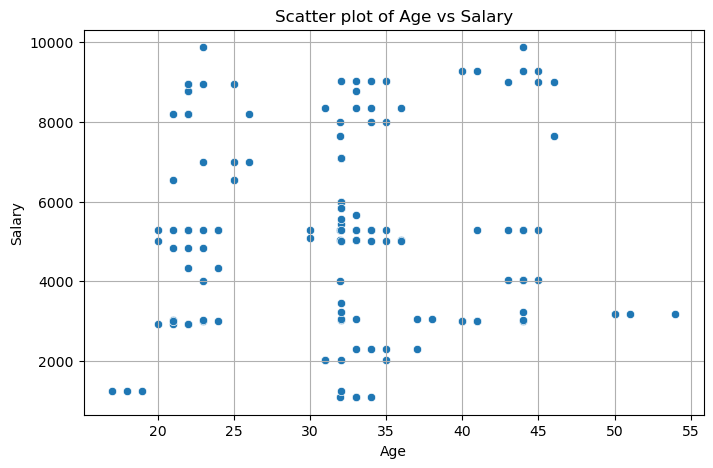

In [18]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='age', y='salary')
plt.title('Scatter plot of Age vs Salary')
plt.xlabel('Age')
plt.ylabel('Salary')
plt.grid(True)
plt.show()


3 Count the number of people from each place and visualize it

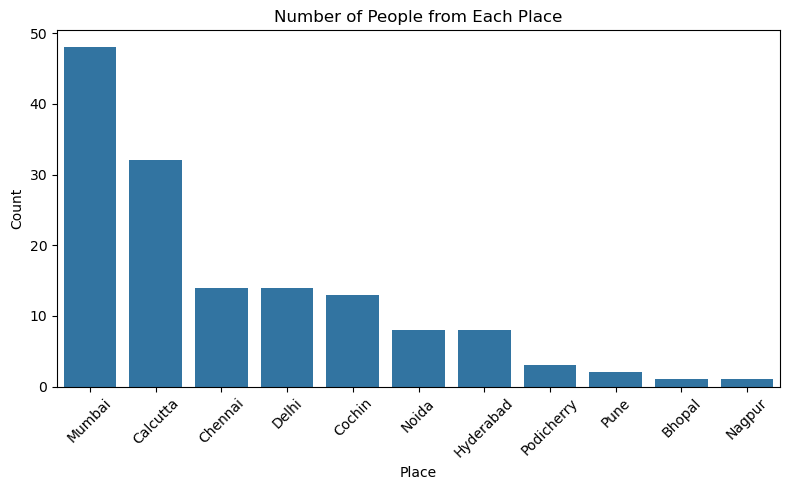

In [19]:
# Replace 'place' with the correct column name if different
place_counts = df['place'].value_counts()

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(x=place_counts.index, y=place_counts.values)
plt.title('Number of People from Each Place')
plt.xlabel('Place')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Data Encoding

1 Identify Categorical Columns

In [20]:
# Identify categorical columns (object or string types)
categorical_cols = df.select_dtypes(include='object').columns
print("Categorical columns:", list(categorical_cols))


Categorical columns: ['company', 'place', 'country']


2 Apply Encoding
One-Hot Encoding for general use:

In [21]:
# One-hot encode all categorical columns
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Display encoded data
df_encoded.head()


,age,salary,gender,company_Congnizant,company_Infosys,company_Infosys Pvt Lmt,company_TCS,company_Tata Consultancy Services,place_Calcutta,place_Chennai,place_Cochin,place_Delhi,place_Hyderabad,place_Mumbai,place_Nagpur,place_Noida,place_Podicherry,place_Pune
0,20.0,5283.471074,0,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False
1,30.0,5283.471074,0,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False
2,35.0,2300.000000,0,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False
3,40.0,3000.000000,0,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False
4,23.0,4000.000000,0,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False


## Feature Scaling (StandardScaler + MinMaxScaler)

1 Apply StandardScaler

In [22]:
from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# Apply on all numeric columns
df_standard_scaled = df_encoded.copy()
df_standard_scaled[df_encoded.columns] = scaler.fit_transform(df_encoded)

# Display scaled data
df_standard_scaled.head()


,age,salary,gender,company_Congnizant,company_Infosys,company_Infosys Pvt Lmt,company_TCS,company_Tata Consultancy Services,place_Calcutta,place_Chennai,place_Cochin,place_Delhi,place_Hyderabad,place_Mumbai,place_Nagpur,place_Noida,place_Podicherry,place_Pune
0,-1.467376,0.000000,-0.534522,-0.118678,-0.652490,-0.118678,1.183216,-0.118678,-0.534522,3.047247,-0.315018,-0.328165,-0.242536,-0.707107,-0.083624,-0.242536,-0.145865,-0.118678
1,-0.248759,0.000000,-0.534522,-0.118678,1.532592,-0.118678,-0.845154,-0.118678,-0.534522,-0.328165,-0.315018,-0.328165,-0.242536,1.414214,-0.083624,-0.242536,-0.145865,-0.118678
2,0.360549,-1.264122,-0.534522,-0.118678,-0.652490,-0.118678,1.183216,-0.118678,1.870829,-0.328165,-0.315018,-0.328165,-0.242536,-0.707107,-0.083624,-0.242536,-0.145865,-0.118678
3,0.969858,-0.967526,-0.534522,-0.118678,1.532592,-0.118678,-0.845154,-0.118678,-0.534522,-0.328165,-0.315018,3.047247,-0.242536,-0.707107,-0.083624,-0.242536,-0.145865,-0.118678
4,-1.101791,-0.543818,-0.534522,-0.118678,-0.652490,-0.118678,1.183216,-0.118678,-0.534522,-0.328165,-0.315018,-0.328165,-0.242536,1.414214,-0.083624,-0.242536,-0.145865,-0.118678


2 Apply MinMaxScaler

In [23]:
from sklearn.preprocessing import MinMaxScaler

# Initialize scaler
minmax_scaler = MinMaxScaler()

# Apply on the same encoded DataFrame
df_minmax_scaled = df_encoded.copy()
df_minmax_scaled[df_encoded.columns] = minmax_scaler.fit_transform(df_encoded)

# Display scaled data
df_minmax_scaled.head()


,age,salary,gender,company_Congnizant,company_Infosys,company_Infosys Pvt Lmt,company_TCS,company_Tata Consultancy Services,place_Calcutta,place_Chennai,place_Cochin,place_Delhi,place_Hyderabad,place_Mumbai,place_Nagpur,place_Noida,place_Podicherry,place_Pune
0,0.081081,0.477350,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.351351,0.477350,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,0.486486,0.137817,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.621622,0.217480,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.162162,0.331285,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
